# 1D CNN — Two-Hand Dynamic Gesture Recognition (multi-variant)

Clean, single-path pipeline for training **several 1D-CNN architecture variants** on the glove data and exporting a comparison PDF.

**Pipeline stages**
1. Configuration (data paths, sensor selection, preprocessing, augmentation, training)
2. Sensor column selection
3. Load CSVs from `DynamicTrainingData/TwoSec`
4. Preprocess: resample to fixed length + Butterworth low-pass filter
5. Train/test split (hold-out)
6. Cross-validation with augmentation **inside** each fold (so the validation set is never augmented)
7. Final retrain on the full training pool and evaluation on hold-out
8. Batch test on `TestData/Jestin/TwoHandDynamic` using per-subfolder labels
9. Save model + log experiment row

Only the CNN-on-sequences path is supported here. Engineered-feature/MLP variants have been removed to keep the notebook readable.


## 1. Imports


In [28]:
import os
import re
import glob
import json
import hashlib
import warnings
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal as scipy_signal
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.max_columns', 20)
print('Imports OK.')


Imports OK.


## 2. Configuration

All knobs in one place. Edit only this cell to run different experiments.


In [29]:
from tensorflow.keras.layers import (
    BatchNormalization, GlobalAveragePooling1D, Activation, Input,
    LSTM, Bidirectional,
)
from tensorflow.keras.models import Sequential


def build_baseline(seq_len, n_chan, n_classes):
    """Original architecture from the notebook."""
    m = Sequential([
        Input(shape=(seq_len, n_chan)),
        Conv1D(32, 4, activation='relu'),
        MaxPooling1D(2),
        Conv1D(64, 4, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax'),
    ], name='Baseline')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def build_shallow(seq_len, n_chan, n_classes):
    """Single Conv block — fewer params, faster to train."""
    m = Sequential([
        Input(shape=(seq_len, n_chan)),
        Conv1D(32, 5, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax'),
    ], name='Shallow')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def build_deep(seq_len, n_chan, n_classes):
    """Three Conv blocks — more representational depth."""
    m = Sequential([
        Input(shape=(seq_len, n_chan)),
        Conv1D(32, 4, activation='relu'),
        MaxPooling1D(2),
        Conv1D(64, 4, activation='relu'),
        MaxPooling1D(2),
        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(n_classes, activation='softmax'),
    ], name='Deep')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def build_bn_gap(seq_len, n_chan, n_classes):
    """BatchNorm + GlobalAveragePooling — typically better generalisation, fewer params."""
    m = Sequential([
        Input(shape=(seq_len, n_chan)),
        Conv1D(32, 4, padding='same'),
        BatchNormalization(), Activation('relu'),
        MaxPooling1D(2),
        Conv1D(64, 4, padding='same'),
        BatchNormalization(), Activation('relu'),
        MaxPooling1D(2),
        Conv1D(128, 3, padding='same'),
        BatchNormalization(), Activation('relu'),
        GlobalAveragePooling1D(),
        Dropout(0.3),
        Dense(n_classes, activation='softmax'),
    ], name='BN_GAP')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def build_wide_kernel(seq_len, n_chan, n_classes):
    """Wider kernels — larger temporal receptive field per layer."""
    m = Sequential([
        Input(shape=(seq_len, n_chan)),
        Conv1D(32, 8, activation='relu'),
        MaxPooling1D(2),
        Conv1D(64, 8, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax'),
    ], name='WideKernel')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def build_cnn_lstm(seq_len, n_chan, n_classes):
    """CNN feature extractor → LSTM temporal model.

    Two Conv1D blocks pull out local temporal features, then a single LSTM
    consumes the resulting (T', F) sequence and a final Dense head classifies.
    Conv layers use padding='same' so MaxPooling controls the temporal
    downsampling explicitly.
    """
    m = Sequential([
        Input(shape=(seq_len, n_chan)),
        Conv1D(32, 4, padding='same', activation='relu'),
        MaxPooling1D(2),
        Conv1D(64, 4, padding='same', activation='relu'),
        MaxPooling1D(2),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax'),
    ], name='CNN_LSTM')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


def build_cnn_bilstm(seq_len, n_chan, n_classes):
    """CNN feature extractor → Bidirectional LSTM temporal model.

    Same Conv front-end as CNN_LSTM but the recurrent stage is bidirectional,
    so each timestep's representation sees both past and future context within
    the trial — useful for gestures where the discriminative motion can sit
    anywhere along the trial.
    """
    m = Sequential([
        Input(shape=(seq_len, n_chan)),
        Conv1D(32, 4, padding='same', activation='relu'),
        MaxPooling1D(2),
        Conv1D(64, 4, padding='same', activation='relu'),
        MaxPooling1D(2),
        Dropout(0.3),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax'),
    ], name='CNN_BiLSTM')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m





# ─────────────────────────────────────────────────────────────────────────────
# Model_I_1D — 1-D adaptation of the published 2-D "Model I" architecture
# Original (in image): Conv2D(3x3,32) → MaxPool(2x2) → BN → Conv2D(2x2,64) →
#                      Conv2D(2x2,64) → MaxPool(2x2) → Flatten → Dense(64) →
#                      Dropout(0.5) → Dense(n_classes)
# 1-D translation per user spec: Conv1 kernel=5 stride=3 (sees 5 time steps,
# advances by 3). Remaining layers keep original kernel sizes and strides=1
# to match the original architecture's information-flow pattern.
# At T=90, output shape evolution: 90 → 29 → 28 → 28 → 27 → 26 → 25 → 1600 → 64 → n
# ─────────────────────────────────────────────────────────────────────────────
def build_model_i_1d(seq_len, n_channels, n_classes):
    """1-D adaptation of 'Model I' from the published architecture.
    
    Faithful 1-D translation: each 2-D conv becomes a Conv1D, spatial axis
    collapses to time, channel axis carries all sensors. Conv1 uses
    kernel_size=5, stride=3 (per the design decision: 'observe 5 rows at a time
    with stride 3'). Subsequent convs use the original kernel_size=2, stride=1.
    """
    m = Sequential([
        Input(shape=(seq_len, n_channels)),
        Conv1D(32, kernel_size=5, strides=3, padding='valid', activation='relu'),
        MaxPooling1D(pool_size=2, strides=1),
        BatchNormalization(),
        Conv1D(64, kernel_size=2, strides=1, padding='valid', activation='relu'),
        Conv1D(64, kernel_size=2, strides=1, padding='valid', activation='relu'),
        MaxPooling1D(pool_size=2, strides=1),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(n_classes, activation='softmax'),
    ], name='Model_I_1D')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


# ─────────────────────────────────────────────────────────────────────────────
# Model_II_1D — 1-D adaptation of the published 2-D "Model II" architecture
# Original: Conv2D(32) -> Conv2D(32) -> BN -> MaxPool -> Drop -> LSTM(64,seq)
#           -> Drop -> LSTM(64) -> Drop -> Dense(128) -> BN -> Drop -> Dense(n)
# 1-D translation: same layer stack + ordering. Conv1 kernel=5 stride=3
# (matches Model_I_1D for fair comparison). Conv2 keeps original kernel=3.
# Heavy dropout (0.5) at four points + two BN layers — paper clearly fighting
# overfitting; preserved here since your LOUO setting is similar.
# At T=90: 90 -> 29 -> 27 -> 13 (after pool) -> LSTM sees 13 time steps.
# ─────────────────────────────────────────────────────────────────────────────
def build_model_ii_1d(seq_len, n_channels, n_classes):
    """1-D adaptation of 'Model II' (CNN + stacked LSTM) from the published paper.
    
    Two Conv1D feature-extractor layers + BatchNorm + MaxPool, then a 2-layer
    stacked LSTM classifier with heavy dropout. First LSTM returns full
    sequence; second returns final state only.
    """
    m = Sequential([
        Input(shape=(seq_len, n_channels)),
        Conv1D(32, kernel_size=5, strides=3, padding='valid', activation='relu'),
        Conv1D(32, kernel_size=3, strides=1, padding='valid', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2, strides=2),
        Dropout(0.5),
        LSTM(64, return_sequences=True),
        Dropout(0.5),
        LSTM(64, return_sequences=False),
        Dropout(0.5),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(n_classes, activation='softmax'),
    ], name='Model_II_1D')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


In [30]:
BATCH_TEST_ROOT = '/home/jestin/ThesisRepo/ML/NewTestData/15_Tash/Dynamic'
TEST_USER = BATCH_TEST_ROOT.split('/')[-2]
print(f'Test user: {TEST_USER}')

Test user: 15_Tash


In [31]:
# ── Data locations ───────────────────────────────────────────────────────────
# You can include data from MULTIPLE users / source folders.
#
# Each entry in DATA_PATHS is a folder that DIRECTLY contains gesture-label
# subfolders (e.g. .../Alan/Dynamic, .../Bridgette/Dynamic). All matching label
# folders across these paths are merged by label name, so e.g.
# Alan/Dynamic/Wave and Bridgette/Dynamic/Wave end up in the same "Wave" class.
#
# Tip: comment out a path to exclude that user from training without deleting it.
DATA_PATHS = [
    # '/home/jestin/ThesisRepo/ML/NewTrainingData/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/1_Alan/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/2_Alex/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/3_Anghad/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/4_Daniel/Dynamic',
    # '/home/jestin/ThesisRepo/ML/NewTestData/5_Georgia/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/6_Harry/Dynamic',
    # '/home/jestin/ThesisRepo/ML/NewTestData/7_Henry/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/8_Jestin/Dynamic',
    # '/home/jestin/ThesisRepo/ML/NewTestData/9_Joselyn/Dynamic',
    # '/home/jestin/ThesisRepo/ML/NewTestData/10_Josh/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/11_Mansh/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/12_Marcus/Dynamic',
    # '/home/jestin/ThesisRepo/ML/NewTestData/13_Nat/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/14_StephenV2/Dynamic',
    # '/home/jestin/ThesisRepo/ML/NewTestData/15_Tash/Dynamic',
    # '/home/jestin/ThesisRepo/ML/NewTestData/16_Bella/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/17_Raquel/Dynamic',
    '/home/jestin/ThesisRepo/ML/NewTestData/18_Bridgette/Dynamic'

]


# Backwards-compat shortcut: set DATA_ROOT to a string and leave DATA_PATHS = None
# (or empty) to use the old single-folder workflow.
DATA_ROOT = None

# INCLUDE_LABELS  = None   # None = use every label subfolder found

INCLUDE_LABELS = [
    'Double_Lower',
    # 'Double_Nothing',
    'Double_Pistol_Recoil',
    'Double_Raise',
    'Double_Wiggle',
    'Double_cmere',
    'Drum_Roll',
]


# ── Sensor selection (per-sensor toggles, laid out as a grid) ───────────────
# Each row is one body segment; each column is one sensor position on that
# segment. Flip True/False to include/exclude individual sensors.
#
#   IMU_mid  / IMU_prox  : the two IMUs on the segment (mid = distal,
#                          prox = proximal). Wrist has only one IMU; put it
#                          in the IMU_mid column.
#   Flex_MCP / Flex_PIP  : the two flex sensors on the finger joint.
#   '.'                  : that sensor doesn't physically exist there.
#
# Notes:
#   - palm has no flex sensors. wrist has no flex sensors and no prox IMU.
#   - palm_mid IMUs exist in the CSV but contain no real sensor data
#     (left as False below — flip to True only if your data has them).
#   - Which channels each enabled IMU contributes (YPR / quat / accel) is
#     controlled by the USE_YPR / USE_QUAT / USE_ACCEL flags below.

#                       IMU_mid   IMU_prox    Flex_MCP    Flex_PIP
SENSOR_GRID = {
    'left': {
        'palm':      ( False,      False,        '.',        '.'      ),
        'thumb':     ( False,      False,        True,       True     ),
        'index':     ( False,      False,        True,       True     ),
        'middle':    ( False,      False,        True,       True     ),
        'ring':      ( False,      False,        True,       True     ),
        'pinky':     ( False,      False,        True,       True     ),
        'wrist':     ( False,      '.',          '.',        '.'      ),
    },
    'right': {
        'palm':      ( False,      False,        '.',        '.'      ),
        'thumb':     ( False,      False,        True,       True     ),
        'index':     ( False,      False,        True,       True     ),
        'middle':    ( False,      False,        True,       True     ),
        'ring':      ( False,      False,        True,       True     ),
        'pinky':     ( False,      False,        True,       True     ),
        'wrist':     ( False,      '.',          '.',        '.'      ),
    },
}

# Column → (suffix, allowed segments). Cells outside allowed segments must be '.'.
_GRID_COLUMNS = [
    ('mid_imu',  None),                                    # all segments (wrist uses this slot)
    ('prox_imu', None),                                    # all segments except wrist
    ('mcp_flex', {'thumb', 'index', 'middle', 'ring', 'pinky'}),
    ('pip_flex', {'thumb', 'index', 'middle', 'ring', 'pinky'}),
]


def _grid_to_sensors(grid):
    """Flatten SENSOR_GRID into the flat SENSORS dict the column builder
    expects: {sensor_id: bool}. Validates '.' placement strictly."""
    out = {}
    for hand, rows in grid.items():
        for seg, cells in rows.items():
            if len(cells) != len(_GRID_COLUMNS):
                raise ValueError(
                    f"{hand}/{seg}: expected {len(_GRID_COLUMNS)} columns, got {len(cells)}")
            for (suffix, allowed), val in zip(_GRID_COLUMNS, cells):
                # Special-case the wrist single-IMU slot
                if seg == 'wrist':
                    if suffix == 'mid_imu':
                        sid = f'{hand}_wrist_imu'
                    else:
                        if val != '.':
                            raise ValueError(
                                f"{hand}/wrist column {suffix!r} must be '.', got {val!r}")
                        continue
                else:
                    if allowed is not None and seg not in allowed:
                        if val != '.':
                            raise ValueError(
                                f"{hand}/{seg} column {suffix!r} must be '.', got {val!r}")
                        continue
                    sid = f'{hand}_{seg}_{suffix}'
                if val == '.':
                    continue                                # empty cell — sensor not present
                if not isinstance(val, bool):
                    raise ValueError(
                        f"{hand}/{seg}/{suffix}: expected True/False or '.', got {val!r}")
                out[sid] = val
    return out


SENSORS = _grid_to_sensors(SENSOR_GRID)

# ── Legacy coarse selectors (used only when SENSORS is None) ────────────────
# If you set SENSORS = None above, these older coarse toggles are used to
# build the sensor list (preserved for backwards compatibility).
USE_LEFT_HAND  = True
USE_RIGHT_HAND = True
INCLUDE_SEGMENTS = [
    # 'palm_mid',
    # 'palm_prox',
    'thumb', 'index', 'middle', 'ring', 'pinky', 'wrist',
]

# ── IMU channel modalities ──────────────────────────────────────────────────
# For every enabled IMU sensor above, choose which of its channels to include.
# Flex sensors are unaffected by these flags.
USE_YPR        = False    # IMU Euler angles (yaw / pitch / roll, or heading for wrist)
USE_QUAT       = False   # Raw quaternion components (quat_w/x/y/z)
USE_ACCEL      = False    # Linear accelerometer (ax, ay, az)
USE_FLEX       = True    # Master switch: if False, ignore all *_flex entries
                         # in SENSORS regardless of their value.

# ── Preprocessing ────────────────────────────────────────────────────────────
RESAMPLE_TO_N_STEPS    = 90
APPLY_BUTTERWORTH      = True
BUTTERWORTH_CUTOFF_HZ  = 10.0
BUTTERWORTH_ORDER      = 4
SAMPLING_RATE_HZ       = 30.0
# NORMALISATION options:
#   'standard'         - global StandardScaler fit on train (per-feature mean/std). Default.
#   'minmax'           - global MinMaxScaler  fit on train (per-feature 0..1).
#   'per_trial_zscore' - per-trial, per-channel z-score (each trial normalised against its own stats).
#                        Stateless. Removes user-specific DC offsets + amplitude. Use for cross-user generalisation.
#   None               - no scaling.
NORMALISATION          = 'per_trial_zscore'   
                                                                  # 'standard' | 'minmax' | None

# ── Train/test split ─────────────────────────────────────────────────────────
TEST_SIZE             = 0.10
RANDOM_STATE          = 42
STRATIFY_SPLIT        = True

# ── Cross-validation ─────────────────────────────────────────────────────────
RUN_CROSS_VALIDATION  = True
CV_FOLDS              = 7
CV_SHUFFLE            = True

# ── Augmentation (training only, inside each CV fold) ────────────────────────
AUGMENT_TRAINING_DATA          = True
AUGMENTATION_COPIES_PER_SAMPLE = 6
AUGMENTATION_RANDOM_SEED       = 42
AUGMENT_CONFIG = {
    'time_shift':      {'enabled': True,  'apply_prob': 1.0, 'max_shift_steps': 3, 'fill_mode': 'edge'},
    'time_warp':       {'enabled': True,  'apply_prob': 1.0, 'speed_range': (0.90, 1.10)},
    'time_mask':       {'enabled': True,  'apply_prob': 1.0, 'max_masks': 2, 'max_mask_size': 3, 'fill_mode': 'zero'},
    'gaussian_noise':  {'enabled': False,  'apply_prob': 1.0, 'std_ratio': 0.02},
    'amplitude_scale': {'enabled': True,  'apply_prob': 1.0, 'scale_range': (0.9, 1.1)},
    'baseline_offset': {'enabled': True,  'apply_prob': 1.0, 'offset_std_ratio': 0.02},
    'channel_dropout': {'enabled': True,  'apply_prob': 1.0, 'drop_fraction': 0.03, 'fill_mode': 'zero'},
    # Only enable left/right swap if the class label is symmetric under that swap
    'left_right_swap': {'enabled': False, 'apply_prob': 0.5},
}

# ── Training hyperparameters ─────────────────────────────────────────────────
TRAIN_EPOCHS           = 60     # max epochs; EarlyStopping decides when to stop
TRAIN_BATCH_SIZE       = 16
TRAIN_VALIDATION_SPLIT = 0.2    # only used by the final retrain (not by CV)
TRAIN_VERBOSE          = 1

# ── Early stopping ───────────────────────────────────────────────────────────
EARLY_STOPPING_ENABLED          = True
EARLY_STOPPING_MONITOR          = 'val_loss'   # 'val_loss' (min) or 'val_accuracy' (max)
EARLY_STOPPING_PATIENCE         = 5            # epochs with no improvement before stopping
EARLY_STOPPING_MIN_DELTA        = 0.0          # min change to count as improvement
EARLY_STOPPING_RESTORE_BEST     = True         # roll weights back to best-monitor epoch
EARLY_STOPPING_VERBOSE          = 1

# ── Output paths ─────────────────────────────────────────────────────────────
MODEL_OUTPUT_DIR     = Path('/home/jestin/ThesisRepo/ML/NewReports/DynamicReports')
EXPERIMENT_LOG_PATH  = MODEL_OUTPUT_DIR / 'experiment_results.csv'
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Resolve active data paths (supports both DATA_PATHS list and legacy DATA_ROOT)
ACTIVE_DATA_PATHS = []
if DATA_PATHS:
    ACTIVE_DATA_PATHS = [p for p in DATA_PATHS if p and not p.strip().startswith('#')]
if not ACTIVE_DATA_PATHS and DATA_ROOT:
    ACTIVE_DATA_PATHS = [DATA_ROOT]

print('Configuration loaded.')
print(f'  Data paths ({len(ACTIVE_DATA_PATHS)}):')
for p in ACTIVE_DATA_PATHS:
    print(f'    - {p}')


Configuration loaded.
  Data paths (11):
    - /home/jestin/ThesisRepo/ML/NewTestData/1_Alan/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/2_Alex/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/3_Anghad/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/4_Daniel/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/6_Harry/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/8_Jestin/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/11_Mansh/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/12_Marcus/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/14_StephenV2/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/17_Raquel/Dynamic
    - /home/jestin/ThesisRepo/ML/NewTestData/18_Bridgette/Dynamic


In [32]:
VARIANTS = [
    # ('Baseline',   'Conv1D(32,k=4)→Pool→Conv1D(64,k=4)→Pool→Flatten→Dense(64)→Dropout(0.3)→Softmax', build_baseline),
    # ('Shallow',    'Single Conv block: Conv1D(32,k=5)→Pool→Flatten→Dense(32)→Dropout(0.3)→Softmax',           build_shallow),
    # ('Deep',       'Three Conv blocks: Conv1D(32,4)→Conv1D(64,4)→Conv1D(128,3)→Flatten→Dense(128)→Dropout(0.4)→Softmax', build_deep),
    # ('BN_GAP',     'Conv+BN+ReLU ×3 with GlobalAveragePooling1D head — fewer params, less overfit',                build_bn_gap),
    # ('WideKernel', 'Conv1D(32,k=8)→Pool→Conv1D(64,k=8)→Pool→Flatten→Dense(64)→Dropout(0.3)→Softmax', build_wide_kernel),
    # ('CNN_LSTM',   'Conv1D(32,4)→Pool→Conv1D(64,4)→Pool→Dropout→LSTM(64)→Dense(64)→Dropout→Softmax',           build_cnn_lstm),
    # ('CNN_BiLSTM', 'Conv1D(32,4)→Pool→Conv1D(64,4)→Pool→Dropout→BiLSTM(64)→Dense(64)→Dropout→Softmax',         build_cnn_bilstm),
    # ('CNN2D_Anatomical',        '2-D Conv over (time, anatomy, modality): Conv2D(32,3x3)→Pool→Conv2D(64,3x3)→Pool→Flatten→Dense(64)→Dropout→Softmax', build_cnn2d_anatomical),
    # ('CNN2D_Anatomical_BN_GAP', '2-D Conv + BN + GAP over (time, anatomy, modality) — fewer params, less overfit',                                            build_cnn2d_anatomical_bn_gap),
    ('Model_I_1D',              '1-D adaptation of published Model I: Conv1D(32,k=5,s=3)→Pool→BN→Conv1D(64,k=2)→Conv1D(64,k=2)→Pool→Flatten→Dense(64)→Drop(0.5)→Softmax', build_model_i_1d),
    ('Model_II_1D',             '1-D adaptation of published Model II (CNN+LSTM): Conv1D(32,k=5,s=3)→Conv1D(32,k=3)→BN→Pool→Drop→LSTM(64,seq)→Drop→LSTM(64)→Drop→Dense(128)→BN→Drop→Softmax', build_model_ii_1d),
]

# Container populated by the CV / retrain / hold-out / batch-test cells below.
# Each entry: dict with name, description, n_params, cv_results, cv_mean, cv_std,
# history, test_accuracy, test_loss, classification_report, y_pred, batch_df,
# batch_correct, batch_total, batch_accuracy, model, model_path, scaler.
variant_results = []
print(f'Configured {len(VARIANTS)} variants:')
for n, d, _ in VARIANTS:
    print(f'  - {n}: {d}')

Configured 2 variants:
  - Model_I_1D: 1-D adaptation of published Model I: Conv1D(32,k=5,s=3)→Pool→BN→Conv1D(64,k=2)→Conv1D(64,k=2)→Pool→Flatten→Dense(64)→Drop(0.5)→Softmax
  - Model_II_1D: 1-D adaptation of published Model II (CNN+LSTM): Conv1D(32,k=5,s=3)→Conv1D(32,k=3)→BN→Pool→Drop→LSTM(64,seq)→Drop→LSTM(64)→Drop→Dense(128)→BN→Drop→Softmax


## 3. Sensor column selection

Build the list of channel names that match the configuration. Two modes:

- **Grid mode** (default): `SENSOR_GRID` lays out per-sensor True/False toggles by hand × segment × position. It flattens into a flat `SENSORS` dict (`{sensor_id: bool}`) and the column builder expands each enabled sensor into the appropriate CSV column names. Modality flags (`USE_YPR / USE_QUAT / USE_ACCEL / USE_FLEX`) still control which channels each active IMU contributes.
- **Legacy mode** (set `SENSORS = None`): falls back to the older `INCLUDE_SEGMENTS` + modality flags for whole-segment on/off control.

`USE_LEFT_HAND` / `USE_RIGHT_HAND` always gate whole hands in both modes.


In [33]:
# ── Build column selector from config ───────────────────────────────────────
SEGMENTS_WITH_FLEX = ['thumb', 'index', 'middle', 'ring', 'pinky']  # palm has no flex
IMU_LOCATIONS = ['mid', 'prox']  # distal phalanx / proximal phalanx


def _imu_channels(prefix, use_ypr, use_quat, use_accel, is_wrist=False):
    """Return the CSV column names contributed by a single IMU sensor."""
    cols = []
    if use_ypr:
        if is_wrist:
            cols += [f'{prefix}_heading', f'{prefix}_pitch', f'{prefix}_roll']
        else:
            cols += [f'{prefix}_yaw', f'{prefix}_pitch', f'{prefix}_roll']
    if use_quat:
        cols += [f'{prefix}_quat_w', f'{prefix}_quat_x',
                 f'{prefix}_quat_y', f'{prefix}_quat_z']
    if use_accel:
        cols += [f'{prefix}_ax', f'{prefix}_ay', f'{prefix}_az']
    return cols


def build_sensor_columns_from_dict(sensors, use_ypr, use_quat, use_accel, use_flex):
    """Expand a SENSORS dict (sensor_id → bool) into CSV column names.

    sensor_id formats:
        {hand}_{segment}_{loc}_imu      e.g. 'left_index_mid_imu'
        {hand}_wrist_imu
        {hand}_{segment}_{joint}_flex   e.g. 'left_index_mcp_flex'
    """
    cols = []
    for sensor_id, enabled in sensors.items():
        if not enabled:
            continue

        if sensor_id.endswith('_imu'):
            base = sensor_id[:-4]          # strip '_imu'
            is_wrist = base.endswith('_wrist')
            cols += _imu_channels(base, use_ypr, use_quat, use_accel, is_wrist=is_wrist)

        elif sensor_id.endswith('_flex'):
            if not use_flex:
                continue                    # master flex switch
            # The flex column name IS the sensor id (e.g. 'left_index_mcp_flex')
            cols.append(sensor_id)

        else:
            print(f"  WARNING: unrecognised sensor id '{sensor_id}' — skipping.")
    return cols


def build_sensor_columns_legacy(hands, segments, use_ypr, use_quat, use_accel, use_flex):
    """Old coarse builder (kept for SENSORS=None fallback)."""
    seg_map = {
        'palm_mid':  'palm', 'palm_prox': 'palm',
        'thumb': 'thumb', 'index': 'index', 'middle': 'middle',
        'ring':  'ring',  'pinky': 'pinky', 'wrist': 'wrist',
    }
    resolved_segs = list(dict.fromkeys([seg_map[s] for s in segments]))

    cols = []
    for hand in hands:
        for seg in resolved_segs:
            if seg == 'wrist':
                cols += _imu_channels(f'{hand}_wrist', use_ypr, use_quat, use_accel, is_wrist=True)
            else:
                for loc in IMU_LOCATIONS:
                    cols += _imu_channels(f'{hand}_{seg}_{loc}', use_ypr, use_quat, use_accel)
                if use_flex and seg in SEGMENTS_WITH_FLEX:
                    cols += [f'{hand}_{seg}_mcp_flex', f'{hand}_{seg}_pip_flex']
    return cols


# ── Resolve the active sensor column list ───────────────────────────────────
resolved_hands = [h for h, on in [('left', USE_LEFT_HAND), ('right', USE_RIGHT_HAND)] if on]

if 'SENSORS' in globals() and SENSORS is not None:
    # Filter SENSORS by enabled hands so USE_LEFT_HAND / USE_RIGHT_HAND still gate
    _filtered_sensors = {
        sid: on for sid, on in SENSORS.items()
        if any(sid.startswith(f'{h}_') for h in resolved_hands)
    }
    SENSOR_COLS = build_sensor_columns_from_dict(
        sensors  = _filtered_sensors,
        use_ypr  = USE_YPR,
        use_quat = USE_QUAT,
        use_accel= USE_ACCEL,
        use_flex = USE_FLEX,
    )
    _enabled_ids = [k for k, v in _filtered_sensors.items() if v]
    print(f'Sensor selection mode: SENSORS dict (from SENSOR_GRID)')
    print(f'Selected {len(SENSOR_COLS)} sensor columns from {len(_enabled_ids)} enabled sensors.')
else:
    SENSOR_COLS = build_sensor_columns_legacy(
        hands    = resolved_hands,
        segments = INCLUDE_SEGMENTS,
        use_ypr  = USE_YPR,
        use_quat = USE_QUAT,
        use_accel= USE_ACCEL,
        use_flex = USE_FLEX,
    )
    print(f'Sensor selection mode: legacy coarse toggles')
    print(f'Selected {len(SENSOR_COLS)} sensor columns.')

# Drop any accidental duplicates while preserving order
SENSOR_COLS = list(dict.fromkeys(SENSOR_COLS))

print('First 10:', SENSOR_COLS[:10])
print('Last  10:', SENSOR_COLS[-10:])


Sensor selection mode: SENSORS dict (from SENSOR_GRID)
Selected 20 sensor columns from 20 enabled sensors.
First 10: ['left_thumb_mcp_flex', 'left_thumb_pip_flex', 'left_index_mcp_flex', 'left_index_pip_flex', 'left_middle_mcp_flex', 'left_middle_pip_flex', 'left_ring_mcp_flex', 'left_ring_pip_flex', 'left_pinky_mcp_flex', 'left_pinky_pip_flex']
Last  10: ['right_thumb_mcp_flex', 'right_thumb_pip_flex', 'right_index_mcp_flex', 'right_index_pip_flex', 'right_middle_mcp_flex', 'right_middle_pip_flex', 'right_ring_mcp_flex', 'right_ring_pip_flex', 'right_pinky_mcp_flex', 'right_pinky_pip_flex']


## 4. Load training data

Walk the label subfolders under `DATA_ROOT` and read each CSV as a `(T, C)` array of the selected sensor channels.


In [34]:
def load_dataset(data_paths, include_labels, sensor_cols):
    """
    Load all CSVs from gesture-label subfolders found inside each path in
    `data_paths`. Trials from the same label across different source folders
    are merged into a single class.

    Returns:
        trials      : list of np.ndarray (per-trial sensor matrices)
        labels      : list of class label strings
        class_names : sorted list of unique class labels
        source_info : list of source label-folder paths per trial (parallel to trials)
    """
    if isinstance(data_paths, str):
        data_paths = [data_paths]
    if not data_paths:
        raise ValueError('No data paths provided. Set DATA_PATHS or DATA_ROOT.')

    resolved_paths = []
    for p in data_paths:
        p_exp = os.path.expanduser(p)
        if not os.path.isdir(p_exp):
            raise FileNotFoundError(
                f"Data path not found: {p_exp!r}\n"
                "Update DATA_PATHS in the Configuration cell."
            )
        resolved_paths.append(p_exp)

    SKIP = {'PDF', 'sdb', 'idk'}
    label_to_folders = {}   # label -> list of full folder paths
    for root in resolved_paths:
        for d in sorted(os.listdir(root)):
            full = os.path.join(root, d)
            if not os.path.isdir(full) or d in SKIP:
                continue
            label_to_folders.setdefault(d, []).append(full)

    if include_labels is not None:
        label_to_folders = {k: v for k, v in label_to_folders.items()
                            if k in include_labels}
    if not label_to_folders:
        raise ValueError('No label folders found. Check DATA_PATHS and INCLUDE_LABELS.')

    label_names = sorted(label_to_folders.keys())
    print(f'Found {len(label_names)} gesture classes across {len(resolved_paths)} source folder(s):')

    trials, labels, source_info = [], [], []
    for label in label_names:
        folders = label_to_folders[label]
        per_source_counts = []
        for folder in folders:
            csv_files = sorted(glob.glob(os.path.join(folder, '*.csv')))
            per_source_counts.append((folder, len(csv_files)))
            for fpath in csv_files:
                try:
                    df = pd.read_csv(fpath)
                    available = [c for c in sensor_cols if c in df.columns]
                    if not available:
                        print(f'    WARNING: no matching sensor columns in {os.path.basename(fpath)}')
                        continue
                    trials.append(df[available].values.astype(np.float32))
                    labels.append(label)
                    source_info.append(folder)
                except Exception as e:
                    print(f'    ERROR loading {os.path.basename(fpath)}: {e}')
        total = sum(c for _, c in per_source_counts)
        extra = ''
        if len(per_source_counts) > 1:
            extra = ' from ' + ', '.join(
                f"{os.path.basename(os.path.dirname(fp))}({n})"
                for fp, n in per_source_counts
            )
        print(f'  [{label}]  →  {total} files{extra}')

    print(f'\nTotal trials loaded: {len(trials)}')
    return trials, labels, label_names, source_info


trials_raw, labels_raw, class_names, source_info = load_dataset(
    ACTIVE_DATA_PATHS, INCLUDE_LABELS, SENSOR_COLS
)

print('\nClass distribution:')
for cls, cnt in sorted(Counter(labels_raw).items()):
    print(f'  {cls}: {cnt} trials')

# Per-source-folder distribution
print('\nTrials per source folder:')
for src, cnt in sorted(Counter(source_info).items()):
    tag = os.sep.join(src.split(os.sep)[-3:])
    print(f'  {tag}: {cnt} trials')


Found 6 gesture classes across 11 source folder(s):
  [Double_Lower]  →  55 files from Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5)
  [Double_Pistol_Recoil]  →  55 files from Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5)
  [Double_Raise]  →  55 files from Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5)
  [Double_Wiggle]  →  54 files from Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(4), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5)
  [Double_cmere]  →  56 files from Dynamic(5), Dynamic(5), Dynamic(6), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5)
  [Drum_Roll]  →  50 files from Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(5), Dynamic(0), Dynam

## 5. Preprocessing

1. Resample every trial to a fixed length so the CNN gets a constant input shape.
2. Optional zero-phase Butterworth low-pass filter to smooth high-frequency noise.


In [35]:
def resample_trial(trial, n_steps):
    """Linear resample (T, C) → (n_steps, C)."""
    T, C = trial.shape
    if T == n_steps:
        return trial.astype(np.float32, copy=False)
    old_idx = np.linspace(0, 1, T)
    new_idx = np.linspace(0, 1, n_steps)
    out = np.zeros((n_steps, C), dtype=np.float32)
    for c in range(C):
        out[:, c] = np.interp(new_idx, old_idx, trial[:, c])
    return out


def apply_butterworth(trials, cutoff, order, fs):
    """Zero-phase low-pass filter applied per channel."""
    nyq = fs / 2.0
    norm_cutoff = cutoff / nyq
    if norm_cutoff >= 1.0:
        print(f'  WARNING: cutoff {cutoff} Hz >= Nyquist {nyq} Hz — skipping filter.')
        return trials
    b, a = scipy_signal.butter(order, norm_cutoff, btype='low', analog=False)
    return [scipy_signal.filtfilt(b, a, t, axis=0).astype(np.float32) for t in trials]


# Resample
if RESAMPLE_TO_N_STEPS is not None:
    trials_resampled = [resample_trial(t, RESAMPLE_TO_N_STEPS) for t in trials_raw]
    print(f'Resampled all trials to {RESAMPLE_TO_N_STEPS} time steps.')
else:
    trials_resampled = trials_raw

# Filter
if APPLY_BUTTERWORTH:
    trials_filtered = apply_butterworth(trials_resampled, BUTTERWORTH_CUTOFF_HZ,
                                        BUTTERWORTH_ORDER, SAMPLING_RATE_HZ)
    print(f'Butterworth low-pass: cutoff={BUTTERWORTH_CUTOFF_HZ} Hz, order={BUTTERWORTH_ORDER}.')
else:
    trials_filtered = trials_resampled
    print('Butterworth filter skipped.')

sequence_length, n_channels = trials_filtered[0].shape
print(f'Trial shape: ({sequence_length}, {n_channels})  (time_steps × channels)')


Resampled all trials to 90 time steps.
Butterworth low-pass: cutoff=10.0 Hz, order=4.
Trial shape: (90, 20)  (time_steps × channels)


## 6. Build X, y and the train/test split

We stack all trials into a single `(N, T, C)` tensor, encode labels, then carve off a stratified hold-out test set. The hold-out set is **never** seen during training, augmentation, or scaler fitting.


In [36]:
X = np.stack(trials_filtered, axis=0).astype(np.float32)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

le = LabelEncoder()
y = le.fit_transform(labels_raw)
n_classes = len(le.classes_)
print(f'X shape: {X.shape}    y shape: {y.shape}    n_classes: {n_classes}')
print('Label mapping:', dict(zip(le.classes_, range(n_classes))))

X_train_pool, X_test, y_train_pool, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y if STRATIFY_SPLIT and n_classes > 1 else None,
)
print(f'Train pool: {X_train_pool.shape}    Hold-out test: {X_test.shape}')


X shape: (325, 90, 20)    y shape: (325,)    n_classes: 6
Label mapping: {np.str_('Double_Lower'): 0, np.str_('Double_Pistol_Recoil'): 1, np.str_('Double_Raise'): 2, np.str_('Double_Wiggle'): 3, np.str_('Double_cmere'): 4, np.str_('Drum_Roll'): 5}
Train pool: (292, 90, 20)    Hold-out test: (33, 90, 20)


## 7. Augmentation helpers

Each augmentation operates on a single `(T, C)` trial and is applied probabilistically per `AUGMENT_CONFIG`. `augment_training_set` produces `copies_per_sample` augmented variants per original trial and concatenates them with the originals.

Augmentation is applied **inside** each CV fold's training split — the fold's validation split is left untouched, just like the hold-out test set.


In [37]:
def _resize_linear(trial, target_steps):
    T, C = trial.shape
    if T == target_steps:
        return trial.astype(np.float32, copy=False)
    old_idx = np.linspace(0, 1, T)
    new_idx = np.linspace(0, 1, target_steps)
    out = np.zeros((target_steps, C), dtype=np.float32)
    for c in range(C):
        out[:, c] = np.interp(new_idx, old_idx, trial[:, c])
    return out


def aug_time_shift(trial, max_shift_steps=3, fill_mode='edge', rng=None):
    rng = rng or np.random.default_rng()
    if max_shift_steps <= 0:
        return trial.copy()
    shift = int(rng.integers(-max_shift_steps, max_shift_steps + 1))
    if shift == 0:
        return trial.copy()
    out = np.empty_like(trial)
    out[:] = 0.0 if fill_mode == 'zero' else (trial[0] if shift > 0 else trial[-1])
    if shift > 0:
        out[shift:] = trial[:-shift]
    else:
        out[:shift] = trial[-shift:]
    return out


def aug_time_warp(trial, speed_range=(0.9, 1.1), rng=None):
    rng = rng or np.random.default_rng()
    factor = float(rng.uniform(*speed_range))
    T = trial.shape[0]
    warped_steps = max(4, int(round(T * factor)))
    return _resize_linear(_resize_linear(trial, warped_steps), T)


def aug_time_mask(trial, max_masks=2, max_mask_size=3, fill_mode='zero', rng=None):
    rng = rng or np.random.default_rng()
    out = trial.copy()
    T, C = out.shape
    n_masks = int(rng.integers(1, max_masks + 1)) if max_masks > 0 else 0
    for _ in range(n_masks):
        size = int(rng.integers(1, max_mask_size + 1))
        start = int(rng.integers(0, max(1, T - size + 1)))
        if fill_mode == 'mean':
            out[start:start+size] = out.mean(axis=0, keepdims=True)
        elif fill_mode == 'noise':
            ch_std = np.std(out, axis=0, keepdims=True)
            out[start:start+size] = rng.normal(0.0, np.maximum(ch_std, 1e-6), size=(size, C))
        else:
            out[start:start+size] = 0.0
    return out


def aug_gaussian_noise(trial, std_ratio=0.02, rng=None):
    rng = rng or np.random.default_rng()
    ch_std = np.std(trial, axis=0, keepdims=True)
    noise_std = np.maximum(ch_std * std_ratio, 1e-6)
    return (trial + rng.normal(0.0, noise_std, size=trial.shape)).astype(np.float32)


def aug_amplitude_scale(trial, scale_range=(0.95, 1.05), rng=None):
    rng = rng or np.random.default_rng()
    scale = rng.uniform(scale_range[0], scale_range[1], size=(1, trial.shape[1]))
    return (trial * scale).astype(np.float32)


def aug_baseline_offset(trial, offset_std_ratio=0.02, rng=None):
    rng = rng or np.random.default_rng()
    ch_std = np.std(trial, axis=0, keepdims=True)
    offset_std = np.maximum(ch_std * offset_std_ratio, 1e-6)
    offset = rng.normal(0.0, offset_std, size=(1, trial.shape[1]))
    return (trial + offset).astype(np.float32)


def aug_channel_dropout(trial, drop_fraction=0.03, fill_mode='zero', rng=None):
    rng = rng or np.random.default_rng()
    out = trial.copy()
    C = out.shape[1]
    n_drop = max(1, int(round(C * drop_fraction))) if drop_fraction > 0 else 0
    if n_drop == 0:
        return out
    idx = rng.choice(C, size=min(n_drop, C), replace=False)
    if fill_mode == 'mean':
        out[:, idx] = out.mean(axis=0, keepdims=True)[:, idx]
    else:
        out[:, idx] = 0.0
    return out


def aug_left_right_swap(trial, sensor_cols, rng=None):
    out = trial.copy()
    name_to_idx = {col: i for i, col in enumerate(sensor_cols)}
    for col in sensor_cols:
        if col.startswith('left'):
            partner = 'right' + col[4:]
            if partner in name_to_idx:
                i, j = name_to_idx[col], name_to_idx[partner]
                out[:, i], out[:, j] = trial[:, j], trial[:, i]
    return out


def apply_augmentations(trial, sensor_cols, config, rng):
    """Apply each augmentation independently with its own probability."""
    out = trial.astype(np.float32, copy=True)

    def _drop_meta(cfg):
        return {k: v for k, v in cfg.items() if k not in ('enabled', 'apply_prob')}

    def _maybe(name, fn, **extra):
        cfg = config.get(name, {})
        if cfg.get('enabled', False) and rng.random() < cfg.get('apply_prob', 1.0):
            return fn(out, **_drop_meta(cfg), **extra, rng=rng)
        return out

    out = _maybe('time_shift',      aug_time_shift)
    out = _maybe('time_warp',       aug_time_warp)
    out = _maybe('time_mask',       aug_time_mask)
    out = _maybe('gaussian_noise',  aug_gaussian_noise)
    out = _maybe('amplitude_scale', aug_amplitude_scale)
    out = _maybe('baseline_offset', aug_baseline_offset)
    out = _maybe('channel_dropout', aug_channel_dropout)
    if config.get('left_right_swap', {}).get('enabled', False) \
            and rng.random() < config['left_right_swap'].get('apply_prob', 1.0):
        out = aug_left_right_swap(out, sensor_cols=sensor_cols, rng=rng)

    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def augment_training_set(X_tr, y_tr, sensor_cols, config, copies_per_sample=1, random_state=42):
    if copies_per_sample <= 0 or len(X_tr) == 0:
        return X_tr, y_tr
    rng = np.random.default_rng(random_state)
    X_aug, y_aug = [], []
    for trial, label in zip(X_tr, y_tr):
        for _ in range(copies_per_sample):
            X_aug.append(apply_augmentations(trial, sensor_cols, config, rng))
            y_aug.append(label)
    X_combined = np.concatenate([X_tr, np.stack(X_aug, axis=0)], axis=0)
    y_combined = np.concatenate([y_tr, np.array(y_aug, dtype=y_tr.dtype)], axis=0)
    return X_combined, y_combined


## 8. CNN model and scaler helper

`scale_train_val_test` fits the scaler on the training fold only, then applies it to validation and to a copy of the hold-out test set so we always have a correctly-scaled view of the test set per fold.


In [38]:
def build_cnn_model(sequence_length, n_channels, n_classes):
    model = Sequential([
        Conv1D(32, kernel_size=4, activation='relu', input_shape=(sequence_length, n_channels)),
        MaxPooling1D(pool_size=2),
        Conv1D(64, kernel_size=4, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax'),
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


class PerTrialZScoreScaler:
    """Per-trial, per-channel z-score normalisation (stateless).

    For each trial independently, computes per-channel mean and std along the
    time axis, then standardises that trial: x' = (x - mean_per_channel) / std_per_channel.

    Key property: nothing is *fit* on training data. Each trial is normalised
    against its own statistics, so user-specific DC offsets and amplitude
    differences are removed before the model ever sees the trial. This is the
    standard transform for cross-user IMU/wearable generalisation.

    Stateless API matches sklearn scalers (fit/transform/fit_transform) so the
    rest of the pipeline (CV loop, batch-test runner) calls it transparently.
    """
    EPS = 1e-8  # avoid division by zero on constant channels

    def fit(self, X, y=None):
        return self  # nothing to fit

    def transform(self, X):
        # X shape: (N*T, C) when called via the flatten-then-reshape pattern,
        # or (N, T, C) when called directly. Handle both.
        return X  # placeholder — scale_sets handles the per-trial logic directly

    def fit_transform(self, X, y=None):
        return self.transform(X)


def _apply_per_trial_zscore(X):
    """Per-trial, per-channel standardisation on a (N, T, C) tensor."""
    if len(X) == 0:
        return X
    mean = X.mean(axis=1, keepdims=True)                                      # (N, 1, C)
    std  = X.std(axis=1, keepdims=True)                                       # (N, 1, C)
    return ((X - mean) / (std + PerTrialZScoreScaler.EPS)).astype(np.float32)


def make_scaler(kind):
    if kind == 'standard':
        return StandardScaler()
    if kind == 'minmax':
        return MinMaxScaler()
    if kind in ('per_trial_zscore', 'zscore_per_trial'):
        return PerTrialZScoreScaler()
    return None


def scale_sets(X_train, X_val, X_test, kind):
    """Fit on train only; transform val and test.

    For per_trial_zscore: stateless, each trial standardised against itself.
    For standard/minmax:  classic global fit on train, applied to val/test.
    """
    scaler = make_scaler(kind)
    if scaler is None:
        return X_train, X_val, X_test, None

    # Per-trial z-score is stateless — no fitting, just apply independently
    if isinstance(scaler, PerTrialZScoreScaler):
        Xt = _apply_per_trial_zscore(X_train)
        Xv = _apply_per_trial_zscore(X_val) if len(X_val) else X_val
        Xs = _apply_per_trial_zscore(X_test) if len(X_test) else X_test
        return Xt, Xv, Xs, scaler

    # Classic global scaler path
    Nt, T, C = X_train.shape
    Xt = scaler.fit_transform(X_train.reshape(Nt, T * C)).reshape(Nt, T, C).astype(np.float32)
    Xv = scaler.transform(X_val.reshape(X_val.shape[0], T * C)).reshape(X_val.shape[0], T, C).astype(np.float32) \
         if len(X_val) else X_val
    Xs = scaler.transform(X_test.reshape(X_test.shape[0], T * C)).reshape(X_test.shape[0], T, C).astype(np.float32) \
         if len(X_test) else X_test
    return Xt, Xv, Xs, scaler


## 8b. CNN architecture variants

We compare several 1D-CNN architectures using the same data, splits, CV folds, augmentation, scaler, and training loop. Each entry in `VARIANTS` is `(name, description, builder)` and the rest of the notebook iterates over it.

Variants:

- **Baseline** — the original 2-block CNN.
- **Shallow** — single Conv block, fewer params.
- **Deep** — three Conv blocks for more depth.
- **BN_GAP** — BatchNorm + GlobalAveragePooling head, typically generalises better.
- **WideKernel** — larger Conv kernels for a bigger temporal receptive field.
- **CNN_LSTM** — Conv1D front-end feeding an LSTM that models temporal dynamics across the gesture.
- **CNN_BiLSTM** — same Conv front-end, but a Bidirectional LSTM so each step sees both past and future context within the trial.


## 9. Cross-validation (augmentation inside each fold)

For every fold:
1. Split `X_train_pool` into fold train / fold val.
2. Augment **only** fold train.
3. Fit scaler on fold train; transform fold val and the (separate) hold-out test.
4. Train a fresh CNN; record validation accuracy.

We keep the best-fold model as a starting point, but the final reported test accuracy comes from a clean retrain on the full training pool (next cell).


In [39]:
# Per-variant cross-validation. Reuses augment_training_set / scale_sets / build_*
# from the helper cells above. The familiar legacy variables (cv_histories,
# cv_fold_results, cv_mean_accuracy, cv_std_accuracy, best_cv_fold_index) end up
# pointing at the LAST variant trained, so existing downstream cells still run.
import tensorflow as tf

variant_results = []  # reset on re-run

for v_name, v_desc, v_builder in VARIANTS:
    print(f'\n{"="*72}\n  Variant: {v_name}\n{"="*72}')
    cv_histories = []
    cv_fold_results = []
    cv_mean_accuracy = None
    cv_std_accuracy = None
    best_cv_fold_index = None

    if RUN_CROSS_VALIDATION and CV_FOLDS > 1:
        skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=CV_SHUFFLE,
                              random_state=RANDOM_STATE if CV_SHUFFLE else None)
        for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X_train_pool, y_train_pool), start=1):
            X_tr, y_tr = X_train_pool[tr_idx].copy(), y_train_pool[tr_idx].copy()
            X_va, y_va = X_train_pool[va_idx].copy(), y_train_pool[va_idx].copy()

            if AUGMENT_TRAINING_DATA:
                X_tr, y_tr = augment_training_set(
                    X_tr, y_tr,
                    sensor_cols=SENSOR_COLS,
                    config=AUGMENT_CONFIG,
                    copies_per_sample=AUGMENTATION_COPIES_PER_SAMPLE,
                    random_state=AUGMENTATION_RANDOM_SEED + fold_idx,
                )

            X_tr_s, X_va_s, _, _ = scale_sets(X_tr, X_va, X_test, NORMALISATION)

            # 2-D variants reshape (N, T, C) -> (N, T, R, M) on the anatomical grid
            _is_2d = v_name.startswith('CNN2D_')
            if _is_2d:
                X_tr_in = reshape_to_grid(X_tr_s)
                X_va_in = reshape_to_grid(X_va_s)
            else:
                X_tr_in, X_va_in = X_tr_s, X_va_s

            tf.keras.backend.clear_session()
            tf.random.set_seed(RANDOM_STATE + fold_idx)
            if _is_2d:
                fold_model = v_builder(sequence_length, GRID_R, GRID_M, n_classes)
            else:
                fold_model = v_builder(sequence_length, n_channels, n_classes)
            _cbs = []
            if EARLY_STOPPING_ENABLED:
                _cbs.append(tf.keras.callbacks.EarlyStopping(
                    monitor=EARLY_STOPPING_MONITOR,
                    patience=EARLY_STOPPING_PATIENCE,
                    min_delta=EARLY_STOPPING_MIN_DELTA,
                    mode=('max' if EARLY_STOPPING_MONITOR.endswith('accuracy') else 'min'),
                    restore_best_weights=EARLY_STOPPING_RESTORE_BEST,
                    verbose=EARLY_STOPPING_VERBOSE,
                ))
            history = fold_model.fit(
                X_tr_in, y_tr,
                epochs=TRAIN_EPOCHS, batch_size=TRAIN_BATCH_SIZE,
                validation_data=(X_va_in, y_va), verbose=TRAIN_VERBOSE,
                callbacks=_cbs,
            )
            val_pred = np.argmax(fold_model.predict(X_va_in, verbose=0), axis=1)
            val_acc = float(accuracy_score(y_va, val_pred))

            _epochs_run = len(history.history.get('loss', []))
            _best_epoch = (int(np.argmin(history.history['val_loss'])) + 1
                            if 'val_loss' in history.history else _epochs_run)
            cv_histories.append(history.history)
            cv_fold_results.append({
                'fold': fold_idx,
                'train_after_aug': int(X_tr.shape[0]),
                'val_samples': int(len(va_idx)),
                'val_accuracy': val_acc,
                'best_val_accuracy': float(max(history.history.get('val_accuracy', [val_acc]))),
                'final_val_accuracy': float(history.history.get('val_accuracy', [val_acc])[-1]),
                'epochs_run': _epochs_run,
                'best_epoch': _best_epoch,
            })
            print(f'  Fold {fold_idx}/{CV_FOLDS}: val_acc={val_acc:.4f}  (epochs_run={_epochs_run}, best_epoch={_best_epoch})')

        val_accs = [r['val_accuracy'] for r in cv_fold_results]
        cv_mean_accuracy = float(np.mean(val_accs))
        cv_std_accuracy  = float(np.std(val_accs))
        best_cv_fold_index = int(np.argmax(val_accs)) + 1
        print(f'  CV mean: {cv_mean_accuracy:.4f} ± {cv_std_accuracy:.4f}, best fold {best_cv_fold_index}')

    variant_results.append({
        'name': v_name,
        'description': v_desc,
        'builder': v_builder,
        'cv_histories': cv_histories,
        'cv_fold_results': cv_fold_results,
        'cv_mean': cv_mean_accuracy,
        'cv_std':  cv_std_accuracy,
        'best_cv_fold_index': best_cv_fold_index,
    })



  Variant: Model_I_1D
Epoch 1/60


I0000 00:00:1778820875.217092 2585899 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_215405__.38


102/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1627 - loss: 1.9408

I0000 00:00:1778820877.595578 2585895 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_215405__.38


110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.1617 - loss: 1.8517 - val_accuracy: 0.1429 - val_loss: 1.7916
Epoch 2/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1994 - loss: 1.7831 - val_accuracy: 0.2381 - val_loss: 1.7743
Epoch 3/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2040 - loss: 1.7624 - val_accuracy: 0.2857 - val_loss: 1.7345
Epoch 4/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2429 - loss: 1.7225 - val_accuracy: 0.2143 - val_loss: 1.7158
Epoch 5/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3069 - loss: 1.6480 - val_accuracy: 0.2619 - val_loss: 1.6753
Epoch 6/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3309 - loss: 1.6037 - val_accuracy: 0.3095 - val_loss: 1.7407
Epoch 7/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3943 - loss: 1.4992 - val_accuracy: 0.1905 - val_loss: 1.8772
Epoch 8/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4154 - loss: 1.4238 - val_accuracy: 0.2381 - val

...

110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.1725 - loss: 1.8472 - val_accuracy: 0.1951 - val_loss: 1.7848
Epoch 2/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1964 - loss: 1.7843 - val_accuracy: 0.2195 - val_loss: 1.7719
Epoch 3/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1998 - loss: 1.7686 - val_accuracy: 0.2439 - val_loss: 1.7558
Epoch 4/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2516 - loss: 1.7277 - val_accuracy: 0.2927 - val_loss: 1.7218
Epoch 5/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2903 - loss: 1.6608 - val_accuracy: 0.2439 - val_loss: 1.8008
Epoch 6/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3142 - loss: 1.6052 - val_accuracy: 0.3415 - val_loss: 1.7693
Epoch 7/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3830 - loss: 1.5078 - val_accuracy: 0.3171 - val_loss: 1.6062
Epoch 8/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4252 - loss: 1.4052 - val_accuracy: 0.3171 - val

I0000 00:00:1778820958.450711 2585898 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_264906__.38


107/110 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1559 - loss: 1.9229

I0000 00:00:1778820960.459248 2585899 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_264906__.38


110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.1679 - loss: 1.8415 - val_accuracy: 0.0976 - val_loss: 1.7924
Epoch 2/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1992 - loss: 1.7789 - val_accuracy: 0.2439 - val_loss: 1.7828
Epoch 3/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2203 - loss: 1.7561 - val_accuracy: 0.1463 - val_loss: 1.8000
Epoch 4/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2698 - loss: 1.7121 - val_accuracy: 0.2439 - val_loss: 1.7928
Epoch 5/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3090 - loss: 1.6447 - val_accuracy: 0.2439 - val_loss: 1.7796
Epoch 6/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3449 - loss: 1.5660 - val_accuracy: 0.2439 - val_loss: 1.7935
Epoch 7/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3671 - loss: 1.5052 - val_accuracy: 0.1951 - val_loss: 1.8135
Epoch 8/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4098 - loss: 1.4120 - val_accuracy: 0.1707 - val

## 10. Final retrain on the full training pool

CV gave us an honest estimate of generalisation. Now we retrain on the whole training pool with augmentation, fit a fresh scaler, and evaluate on the hold-out test set. This `model` and `scaler` are what get used for batch testing.


In [40]:
# Final retrain on the full training pool — once per variant. The familiar
# `model`, `scaler`, `history`, `X_train_final`, `y_train_final`, `X_test_final`
# variables end up pointing at the LAST variant for compatibility with cells
# 23/25/27 if you ever decide to skip the variants loop and run a single one.
import tensorflow as tf

# Build the training set once (same data + augmentation seed for fair comparison)
if AUGMENT_TRAINING_DATA:
    X_tr_full, y_tr_full = augment_training_set(
        X_train_pool, y_train_pool,
        sensor_cols=SENSOR_COLS,
        config=AUGMENT_CONFIG,
        copies_per_sample=AUGMENTATION_COPIES_PER_SAMPLE,
        random_state=AUGMENTATION_RANDOM_SEED,
    )
else:
    X_tr_full, y_tr_full = X_train_pool.copy(), y_train_pool.copy()
print(f'Final training set size: {X_tr_full.shape[0]} (orig pool {X_train_pool.shape[0]})')

for entry in variant_results:
    print(f'\n── Final retrain: {entry["name"]} ──')

    # Fresh scaler per variant (fit on full augmented pool, applied to hold-out)
    X_tr_s, _, X_test_s, scaler_v = scale_sets(X_tr_full, X_tr_full[:0], X_test, NORMALISATION)

    # 2-D variants reshape onto the anatomical grid
    _is_2d = entry['name'].startswith('CNN2D_')
    if _is_2d:
        X_tr_in = reshape_to_grid(X_tr_s)
        X_test_in = reshape_to_grid(X_test_s)
    else:
        X_tr_in, X_test_in = X_tr_s, X_test_s

    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE)
    if _is_2d:
        model_v = entry['builder'](sequence_length, GRID_R, GRID_M, n_classes)
    else:
        model_v = entry['builder'](sequence_length, n_channels, n_classes)
    n_params = int(model_v.count_params())
    _cbs = []
    if EARLY_STOPPING_ENABLED:
        _cbs.append(tf.keras.callbacks.EarlyStopping(
            monitor=EARLY_STOPPING_MONITOR,
            patience=EARLY_STOPPING_PATIENCE,
            min_delta=EARLY_STOPPING_MIN_DELTA,
            mode=('max' if EARLY_STOPPING_MONITOR.endswith('accuracy') else 'min'),
            restore_best_weights=EARLY_STOPPING_RESTORE_BEST,
            verbose=EARLY_STOPPING_VERBOSE,
        ))
    history_v = model_v.fit(
        X_tr_in, y_tr_full,
        epochs=TRAIN_EPOCHS, batch_size=TRAIN_BATCH_SIZE,
        validation_split=TRAIN_VALIDATION_SPLIT, verbose=TRAIN_VERBOSE,
        callbacks=_cbs,
    )

    entry.update({
        'model':   model_v,
        'scaler':  scaler_v,
        'history': history_v.history,
        'n_params': n_params,
        'X_test_final': X_test_in,
        'is_2d': _is_2d,
    })
    print(f'  trainable params: {n_params:,}')

# Legacy aliases pointing at the last variant
_last = variant_results[-1]
model         = _last['model']
scaler        = _last['scaler']
history       = type('H', (), {'history': _last['history']})()
X_train_final = X_tr_in     # tensor as fed to the last variant (1-D or 2-D)
y_train_final = y_tr_full
X_test_final  = _last['X_test_final']


Final training set size: 2044 (orig pool 292)

── Final retrain: Model_I_1D ──
Epoch 1/60


I0000 00:00:1778821368.405547 2585902 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_408050__.38


 89/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1906 - loss: 1.9326

I0000 00:00:1778821370.670044 2585902 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_408050__.38


103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.1743 - loss: 1.8383 - val_accuracy: 0.1222 - val_loss: 1.8011
Epoch 2/60
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1976 - loss: 1.7862 - val_accuracy: 0.1174 - val_loss: 1.8143
Epoch 3/60
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2128 - loss: 1.7794 - val_accuracy: 0.1296 - val_loss: 1.8478
Epoch 4/60
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2183 - loss: 1.7556 - val_accuracy: 0.1443 - val_loss: 1.8419
Epoch 5/60
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2691 - loss: 1.7022 - val_accuracy: 0.1663 - val_loss: 1.8490
Epoch 6/60
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3034 - loss: 1.6358 - val_accuracy: 0.1394 - val_loss: 1.8290
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
  trainable params: 118,630

── Final retrain: Model_II_1D ──
Epoch 1/60
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.1602 - loss: 2.4015 - val_accu

## 11. Training curves


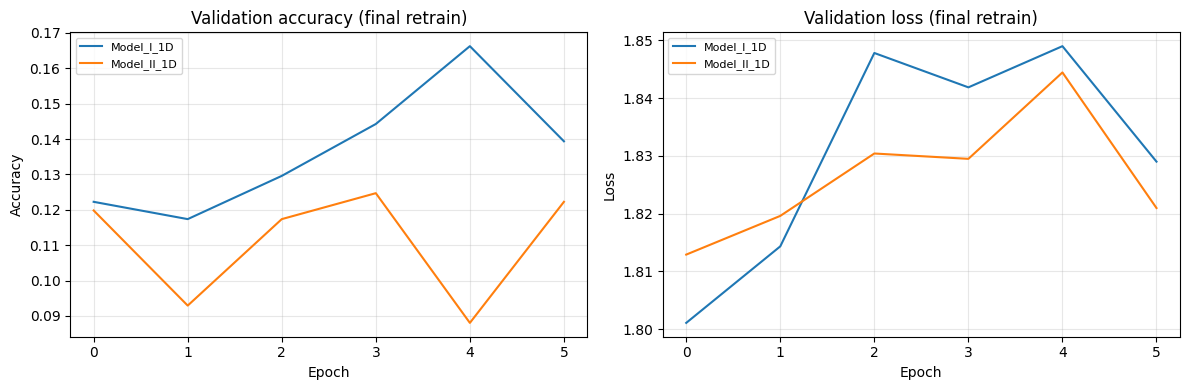

In [41]:
# Overlay validation curves for all variants
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for entry in variant_results:
    h = entry.get('history', {})
    if 'val_accuracy' in h:
        plt.plot(h['val_accuracy'], label=entry['name'])
plt.title('Validation accuracy (final retrain)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(fontsize=8); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
for entry in variant_results:
    h = entry.get('history', {})
    if 'val_loss' in h:
        plt.plot(h['val_loss'], label=entry['name'])
plt.title('Validation loss (final retrain)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(fontsize=8); plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / 'training_curves.png', dpi=140, bbox_inches='tight')
plt.show()


## 12. Hold-out test evaluation


In [42]:
# Hold-out evaluation per variant
for entry in variant_results:
    test_loss_v, test_accuracy_v = entry['model'].evaluate(
        entry['X_test_final'], y_test, verbose=0
    )
    y_pred_v = np.argmax(entry['model'].predict(entry['X_test_final'], verbose=0), axis=1)
    rep_v = classification_report(
        y_test, y_pred_v, target_names=le.classes_, output_dict=True, zero_division=0
    )
    entry.update({
        'test_loss': float(test_loss_v),
        'test_accuracy': float(test_accuracy_v),
        'y_pred': y_pred_v,
        'classification_report': rep_v,
    })
    print(f'{entry["name"]:<12} test_loss={test_loss_v:.4f}  test_acc={test_accuracy_v:.4f}')

print('\nConfusion matrix (last variant):')
print(confusion_matrix(y_test, variant_results[-1]['y_pred']))
print('\nClassification report (last variant):')
print(classification_report(
    y_test, variant_results[-1]['y_pred'], target_names=le.classes_, zero_division=0
))

# Legacy aliases for downstream cells
test_loss     = variant_results[-1]['test_loss']
test_accuracy = variant_results[-1]['test_accuracy']
y_pred        = variant_results[-1]['y_pred']


Model_I_1D   test_loss=1.7899  test_acc=0.1515
Model_II_1D  test_loss=1.7913  test_acc=0.2424

Confusion matrix (last variant):
[[0 2 0 0 3 0]
 [0 4 0 0 2 0]
 [0 3 0 0 3 0]
 [0 1 0 0 4 0]
 [0 2 0 0 4 0]
 [0 3 0 0 2 0]]

Classification report (last variant):
                      precision    recall  f1-score   support

        Double_Lower       0.00      0.00      0.00         5
Double_Pistol_Recoil       0.27      0.67      0.38         6
        Double_Raise       0.00      0.00      0.00         6
       Double_Wiggle       0.00      0.00      0.00         5
        Double_cmere       0.22      0.67      0.33         6
           Drum_Roll       0.00      0.00      0.00         5

            accuracy                           0.24        33
           macro avg       0.08      0.22      0.12        33
        weighted avg       0.09      0.24      0.13        33



## 13. Batch test on TestData/Jestin/TwoHandDynamic

The test folder contains one subfolder per gesture (matching the training class names, sometimes with case differences). We use **the subfolder name** as the ground-truth label — this is far more robust than parsing filenames. Class-name matching is case-insensitive so e.g. `TwoHandDynamic_L_Fist_R_LightBulb` (test) maps to `TwoHandDynamic_L_Fist_R_Lightbulb` (training).


In [43]:
def preprocess_csv_for_cnn(fpath, sensor_cols, resample_n, apply_butter, cutoff, order, fs, scaler,
                            seq_len, n_chan):
    """Read one CSV → (1, seq_len, n_chan) tensor ready for model.predict."""
    df = pd.read_csv(fpath)
    available = [c for c in sensor_cols if c in df.columns]
    if not available:
        raise ValueError('No matching sensor columns')
    if len(available) != len(sensor_cols):
        # Pad missing columns with zeros so the channel order matches training
        data = np.zeros((len(df), len(sensor_cols)), dtype=np.float32)
        idx_map = {c: i for i, c in enumerate(sensor_cols)}
        for c in available:
            data[:, idx_map[c]] = df[c].values.astype(np.float32)
    else:
        data = df[sensor_cols].values.astype(np.float32)

    if resample_n is not None:
        data = resample_trial(data, resample_n)
    if apply_butter:
        data = apply_butterworth([data], cutoff, order, fs)[0]
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    if scaler is not None:
        # PerTrialZScoreScaler is stateless — apply per-trial z-score directly.
        if isinstance(scaler, PerTrialZScoreScaler):
            data = _apply_per_trial_zscore(data[np.newaxis, ...])[0]
        else:
            data = scaler.transform(data.reshape(1, -1)).reshape(seq_len, n_chan).astype(np.float32)

    return data.reshape(1, seq_len, n_chan)


def build_test_label_map(class_names):
    """Case-insensitive map from test-folder class name → training class name."""
    m = {}
    for cls in class_names:
        m[cls.lower()] = cls
    return m


def run_batch_test(test_root, model, scaler, le, sensor_cols, class_names,
                   resample_n, apply_butter, cutoff, order, fs, seq_len, n_chan):
    test_root = os.path.expanduser(test_root)
    if not os.path.isdir(test_root):
        raise FileNotFoundError(f'BATCH_TEST_ROOT not found: {test_root!r}')

    label_map = build_test_label_map(class_names)
    sub_dirs = sorted(d for d in os.listdir(test_root)
                      if os.path.isdir(os.path.join(test_root, d)))
    if not sub_dirs:
        print(f'No subfolders found in {test_root}')
        return None

    correct, total, unrecognised = 0, 0, 0
    per_class = {}
    rows = []
    print(f'Batch testing files from {len(sub_dirs)} subfolders under {test_root}')
    print('-' * 100)

    for sub in sub_dirs:
        true_label = label_map.get(sub.lower())
        sub_path = os.path.join(test_root, sub)
        csv_files = sorted(f for f in glob.glob(os.path.join(sub_path, '*.csv'))
                           if not os.path.basename(f).startswith('_'))
        if true_label is None:
            print(f'  ? subfolder {sub!r} has no matching training class — skipping ({len(csv_files)} files)')
            unrecognised += len(csv_files)
            continue

        per_class.setdefault(true_label, {'correct': 0, 'total': 0})

        for fpath in csv_files:
            fname = os.path.basename(fpath)
            try:
                x = preprocess_csv_for_cnn(
                    fpath, sensor_cols,
                    resample_n, apply_butter, cutoff, order, fs,
                    scaler, seq_len, n_chan,
                )
                probs = model.predict(x, verbose=0)[0]
                pred_idx = int(np.argmax(probs))
                pred = le.inverse_transform([pred_idx])[0]
                conf = float(probs.max())
                ok = (pred == true_label)
                correct += int(ok); total += 1
                per_class[true_label]['correct'] += int(ok)
                per_class[true_label]['total']   += 1
                rows.append({'file': fname, 'true': true_label, 'pred': pred,
                             'confidence': conf, 'correct': ok})
                tag = '✓' if ok else '✗'
                t_short = true_label.replace('TwoHandDynamic_', '')
                p_short = pred.replace('TwoHandDynamic_', '')
                print(f'  {tag} {fname[:50]:<52}  true={t_short:<28}  pred={p_short:<28}  conf={conf:.3f}')
            except Exception as e:
                print(f'  ERROR {fname}: {e}')

    print('-' * 100)
    if total > 0:
        print(f'Overall batch accuracy: {correct/total:.4f}  ({correct}/{total})')
    if unrecognised:
        print(f'Files in unmatched subfolders: {unrecognised}')

    print('\nPer-class accuracy:')
    for cls, d in sorted(per_class.items()):
        if d['total']:
            print(f'  {cls:<55} {d["correct"]/d["total"]:.4f}  ({d["correct"]}/{d["total"]})')

    return pd.DataFrame(rows), correct, total




In [44]:
# Batch test per variant (reuses run_batch_test defined above).
# For 2-D variants, wrap the model with a thin Keras Lambda that accepts
# (1, T, C) input and applies reshape_to_grid before the real model.
from tensorflow.keras.layers import Lambda
from tensorflow.keras.models import Model
import tensorflow as tf

def _wrap_2d_for_batch_test(inner_model, grid_index):
    """Return a Keras model that accepts (B, T, C) and predicts via inner_model on (B, T, R, M)."""
    grid_index_tf = tf.constant(grid_index, dtype=tf.int32)  # shape (R, M)
    mask = tf.cast(grid_index_tf >= 0, tf.float32)              # (R, M)
    safe_idx = tf.maximum(grid_index_tf, 0)                     # (R, M), 0 wherever empty
    def _reshape(x):
        # x: (B, T, C)  ->  gather channels into (B, T, R, M), zero out empty cells
        gathered = tf.gather(x, safe_idx, axis=-1)              # (B, T, R, M)
        return gathered * mask                                  # zero-fill empties
    inp = Input(shape=inner_model.input_shape[1:-1] + (len(SENSOR_COLS),))
    # Note: inner_model.input_shape is (None, T, R, M). We need an outer input of (None, T, C).
    # Rebuild explicitly:
    T_dim = inner_model.input_shape[1]
    outer_in = Input(shape=(T_dim, len(SENSOR_COLS)))
    reshaped = Lambda(_reshape, output_shape=inner_model.input_shape[1:])(outer_in)
    return Model(inputs=outer_in, outputs=inner_model(reshaped))

for entry in variant_results:
    print(f'\n── Batch test: {entry["name"]} ──')
    if entry.get('is_2d', entry['name'].startswith('CNN2D_')):
        # Wrap so run_batch_test (which feeds (1, T, C)) still works
        wrapped = _wrap_2d_for_batch_test(entry['model'], GRID_INDEX)
        _model_for_batch = wrapped
    else:
        _model_for_batch = entry['model']
    res = run_batch_test(
        BATCH_TEST_ROOT, _model_for_batch, entry['scaler'], le,
        SENSOR_COLS, class_names,
        RESAMPLE_TO_N_STEPS, APPLY_BUTTERWORTH, BUTTERWORTH_CUTOFF_HZ, BUTTERWORTH_ORDER,
        SAMPLING_RATE_HZ, sequence_length, n_channels,
    )
    if res is not None:
        df_v, c_v, t_v = res
        entry['batch_df'] = df_v
        entry['batch_correct'] = int(c_v)
        entry['batch_total'] = int(t_v)
        entry['batch_accuracy'] = float(c_v / t_v) if t_v else None
    else:
        entry['batch_df'] = None
        entry['batch_correct'] = 0
        entry['batch_total'] = 0
        entry['batch_accuracy'] = None

print('\n=== Summary across variants ===')
print(f'{"Variant":<12}  {"params":>10}  {"CV":>16}  {"hold-out":>10}  {"batch":>10}')
for e in variant_results:
    cv = f'{e["cv_mean"]:.3f}±{e["cv_std"]:.3f}' if e["cv_mean"] is not None else '—'
    bt = f'{e["batch_accuracy"]:.3f}' if e["batch_accuracy"] is not None else '—'
    print(f'{e["name"]:<12}  {e["n_params"]:>10,}  {cv:>16}  {e["test_accuracy"]:>10.3f}  {bt:>10}')

# Legacy aliases
batch_df = variant_results[-1].get('batch_df')
batch_correct = variant_results[-1].get('batch_correct', 0)
batch_total = variant_results[-1].get('batch_total', 0)
batch_test_accuracy = variant_results[-1].get('batch_accuracy')



── Batch test: Model_I_1D ──
Batch testing files from 7 subfolders under /home/jestin/ThesisRepo/ML/NewTestData/15_Tash/Dynamic
----------------------------------------------------------------------------------------------------
  ✗ glove_data_L_Dynamic_Double_Lower_3s_1_2026-05-04_    true=Double_Lower                  pred=Double_cmere                  conf=0.173
  ✗ glove_data_L_Dynamic_Double_Lower_3s_2_2026-05-04_    true=Double_Lower                  pred=Double_Raise                  conf=0.177
  ✗ glove_data_L_Dynamic_Double_Lower_3s_3_2026-05-04_    true=Double_Lower                  pred=Double_cmere                  conf=0.168
  ✗ glove_data_L_Dynamic_Double_Lower_3s_4_2026-05-04_    true=Double_Lower                  pred=Double_Raise                  conf=0.171
  ✗ glove_data_L_Dynamic_Double_Lower_3s_5_2026-05-04_    true=Double_Lower                  pred=Double_Pistol_Recoil          conf=0.186
  ? subfolder 'Double_Nothing' has no matching training class — skipping (5

## 14. Save model and append experiment row to CSV log


In [45]:
def _to_jsonable(obj):
    if isinstance(obj, dict):  return {str(k): _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [_to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):    return obj.tolist()
    if isinstance(obj, np.integer):    return int(obj)
    if isinstance(obj, np.floating):   return float(obj)
    if isinstance(obj, np.bool_):      return bool(obj)
    return obj


def _stable_json(obj):
    return json.dumps(_to_jsonable(obj), sort_keys=True, separators=(',', ':'))


def build_experiment_row():
    hist = {k: [float(v) for v in vs] for k, vs in history.history.items()}
    row = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'data_paths': _stable_json([str(p) for p in (ACTIVE_DATA_PATHS or [])]),
        'data_paths_count': len(ACTIVE_DATA_PATHS or []),
        'batch_test_root': str(BATCH_TEST_ROOT),
        'sensor_cols_count': len(SENSOR_COLS),
        'sensor_cols': _stable_json(SENSOR_COLS),
        'resample_to_n_steps': RESAMPLE_TO_N_STEPS,
        'apply_butterworth': bool(APPLY_BUTTERWORTH),
        'butterworth_cutoff_hz': BUTTERWORTH_CUTOFF_HZ,
        'butterworth_order': BUTTERWORTH_ORDER,
        'sampling_rate_hz': SAMPLING_RATE_HZ,
        'normalisation': NORMALISATION,
        'test_size': float(TEST_SIZE),
        'random_state': int(RANDOM_STATE),
        'cv_folds': int(CV_FOLDS),
        'run_cross_validation': bool(RUN_CROSS_VALIDATION),
        'cv_shuffle': bool(CV_SHUFFLE),
        'augment_training_data': bool(AUGMENT_TRAINING_DATA),
        'augmentation_copies_per_sample': int(AUGMENTATION_COPIES_PER_SAMPLE),
        'augmentation_random_seed': int(AUGMENTATION_RANDOM_SEED),
        'augmentation_config': _stable_json(AUGMENT_CONFIG),
        'n_classes': int(n_classes),
        'class_names': _stable_json(list(le.classes_)),
        'n_total_samples': int(X.shape[0]),
        'n_train_pool_samples': int(X_train_pool.shape[0]),
        'n_train_after_aug': int(X_train_final.shape[0]),
        'n_test_samples': int(X_test.shape[0]),
        'sequence_length': int(sequence_length),
        'n_channels': int(n_channels),
        'epochs': int(TRAIN_EPOCHS),
        'batch_size': int(TRAIN_BATCH_SIZE),
        'validation_split': float(TRAIN_VALIDATION_SPLIT),
        'cv_mean_accuracy': cv_mean_accuracy,
        'cv_std_accuracy': cv_std_accuracy,
        'cv_best_fold_index': best_cv_fold_index,
        'cv_fold_results_json': _stable_json(cv_fold_results),
        'cv_histories_json': _stable_json(cv_histories),
        'final_train_accuracy': float(history.history['accuracy'][-1]),
        'final_val_accuracy':   float(history.history['val_accuracy'][-1]),
        'final_train_loss':     float(history.history['loss'][-1]),
        'final_val_loss':       float(history.history['val_loss'][-1]),
        'best_val_accuracy':    float(max(history.history['val_accuracy'])),
        'best_val_loss':        float(min(history.history['val_loss'])),
        'test_accuracy':        float(test_accuracy),
        'test_loss':            float(test_loss),
        'batch_test_accuracy':  float(batch_test_accuracy) if batch_test_accuracy is not None else None,
        'history_json': _stable_json(hist),
    }
    sig_payload = {k: v for k, v in row.items() if k != 'timestamp'}
    row['row_signature'] = hashlib.sha256(_stable_json(sig_payload).encode()).hexdigest()
    return row


def append_experiment_row(csv_path=EXPERIMENT_LOG_PATH):
    row = build_experiment_row()
    df_new = pd.DataFrame([row])
    if csv_path.exists():
        df_existing = pd.read_csv(csv_path)
        if 'row_signature' in df_existing.columns and row['row_signature'] in set(df_existing['row_signature'].astype(str)):
            print(f'Identical row already in {csv_path} — not appending.')
            return df_existing
        df_out = pd.concat([df_existing, df_new], ignore_index=True)
    else:
        df_out = df_new
    df_out.to_csv(csv_path, index=False)
    print(f'Experiment log: {csv_path} ({len(df_out)} rows)')
    return df_out


def save_model_artifact():
    timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    sig = build_experiment_row()['row_signature'][:12]
    path = MODEL_OUTPUT_DIR / f'cnn_model_{timestamp}_{sig}.keras'
    model.save(path)
    print(f'Saved model to {path}')
    return path


model_path = save_model_artifact()
experiment_log_df = append_experiment_row()
experiment_log_df.tail(3)


Saved model to /home/jestin/ThesisRepo/ML/NewReports/DynamicReports/cnn_model_2026-05-15_15-03-21_0cb72e885f9a.keras
Experiment log: /home/jestin/ThesisRepo/ML/NewReports/DynamicReports/experiment_results.csv (16 rows)


,timestamp,data_paths,data_paths_count,batch_test_root,sensor_cols_count,sensor_cols,resample_to_n_steps,apply_butterworth,butterworth_cutoff_hz,butterworth_order,...,final_val_accuracy,final_train_loss,final_val_loss,best_val_accuracy,best_val_loss,test_accuracy,test_loss,batch_test_accuracy,history_json,row_signature
13,2026-05-15 14:01:52,"[""/home/jestin/ThesisRepo/ML/NewTestData/1_Ala...",11,/home/jestin/ThesisRepo/ML/NewTestData/15_Tash...,36,"[""left_palm_prox_yaw"",""left_palm_prox_pitch"",""...",90,True,10.0,4,...,0.997555,0.036680,0.015523,0.997555,0.008412,1.000000,0.000220,0.966667,"{""accuracy"":[0.39021405577659607,0.71376144886...",aff270fc510b211c7f38c2c1d022fb06bdc30287570fb7...
14,2026-05-15 14:40:20,"[""/home/jestin/ThesisRepo/ML/NewTestData/1_Ala...",11,/home/jestin/ThesisRepo/ML/NewTestData/15_Tash...,36,"[""left_palm_prox_yaw"",""left_palm_prox_pitch"",""...",90,True,10.0,4,...,1.000000,0.047612,0.000286,1.000000,0.000119,0.969697,0.037205,0.866667,"{""accuracy"":[0.437920480966568,0.7785933017730...",b03f073da9aa57c084c3fa2711d937a03d917f6453ca84...
15,2026-05-15 15:03:21,"[""/home/jestin/ThesisRepo/ML/NewTestData/1_Ala...",11,/home/jestin/ThesisRepo/ML/NewTestData/15_Tash...,20,"[""left_thumb_mcp_flex"",""left_thumb_pip_flex"",""...",90,True,10.0,4,...,0.122249,1.849797,1.820955,0.124694,1.812891,0.242424,1.791266,0.200000,"{""accuracy"":[0.1602446436882019,0.161467894911...",0cb72e885f9a7aad60aaa17b84314252a955207235b878...


## 15. Export PDF report (parameters, paths, results)

Builds a compact PDF summarising the configuration, data locations, CV folds, hold-out and
batch-test results, and the saved model path. Uses only `reportlab` so it works in any env.


In [46]:
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import mm
from reportlab.lib import colors
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, PageBreak
)
from reportlab.lib.enums import TA_LEFT


def _fmt(v, nd=4):
    if v is None:
        return '—'
    if isinstance(v, float):
        return f'{v:.{nd}f}'
    return str(v)


_VAL_STYLE = ParagraphStyle('KVValue', fontName='Helvetica', fontSize=7.5, leading=9.5,
                            textColor=colors.HexColor('#222222'))
_KEY_STYLE = ParagraphStyle('KVKey',   fontName='Helvetica-Bold', fontSize=7.5, leading=9.5,
                            textColor=colors.HexColor('#333333'))


def _wrap(text, style=_VAL_STYLE):
    if isinstance(text, Paragraph):
        return text
    s = str(text).replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
    return Paragraph(s, style)


def _kv_table(rows, col_widths=(50*mm, 135*mm)):
    wrapped = [[_wrap(r[0], _KEY_STYLE), _wrap(r[1], _VAL_STYLE)] for r in rows]
    tbl = Table(wrapped, colWidths=col_widths, hAlign='LEFT')
    tbl.setStyle(TableStyle([
        ('VALIGN',       (0, 0), (-1, -1), 'TOP'),
        ('BOTTOMPADDING',(0, 0), (-1, -1), 1),
        ('TOPPADDING',   (0, 0), (-1, -1), 1),
        ('LINEBELOW',    (0, 0), (-1, -2), 0.25, colors.HexColor('#dddddd')),
    ]))
    return tbl


_CELL_STYLE = ParagraphStyle('CellVal', fontName='Helvetica', fontSize=7,
                             leading=8.5, alignment=1,  # 1 = TA_CENTER
                             textColor=colors.HexColor('#222222'))
_CELL_BOLD  = ParagraphStyle('CellHdr', fontName='Helvetica-Bold', fontSize=7,
                             leading=8.5, alignment=1,
                             textColor=colors.HexColor('#222222'))


def _grid_table(rows, col_widths, font_size=7):
    """Header-row styled grid table (used for the SENSOR_GRID summary)."""
    tbl = Table(rows, colWidths=col_widths, hAlign='LEFT')
    tbl.setStyle(TableStyle([
        ('FONT',         (0, 0), (-1, -1), 'Helvetica',     font_size),
        ('FONT',         (0, 0), (-1,  0), 'Helvetica-Bold', font_size),
        ('BACKGROUND',   (0, 0), (-1,  0), colors.HexColor('#eef2f7')),
        ('GRID',         (0, 0), (-1, -1), 0.25, colors.HexColor('#cccccc')),
        ('VALIGN',       (0, 0), (-1, -1), 'MIDDLE'),
        ('ALIGN',        (1, 1), (-1, -1), 'CENTER'),
        ('BOTTOMPADDING',(0, 0), (-1, -1), 1.5),
        ('TOPPADDING',   (0, 0), (-1, -1), 1.5),
    ]))
    return tbl


def _section(title, styles):
    return Paragraph(f'<b>{title}</b>', styles['Section'])


def _build_comparison_chart(variant_results, out_path, batch_subject):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    labels    = [r['name'] for r in variant_results]
    cv_means  = [r['cv_mean'] if r['cv_mean'] is not None else 0 for r in variant_results]
    cv_stds   = [r['cv_std']  if r['cv_std']  is not None else 0 for r in variant_results]
    test_accs = [r['test_accuracy'] for r in variant_results]
    batch_acc = [r['batch_accuracy'] if r['batch_accuracy'] is not None else 0 for r in variant_results]
    x = np.arange(len(labels)); w = 0.27
    ax.bar(x - w, cv_means,  w, yerr=cv_stds, capsize=3, label=f'CV mean (k={CV_FOLDS})', color='#4c78a8')
    ax.bar(x,     test_accs, w, label='Hold-out', color='#f58518')
    ax.bar(x + w, batch_acc, w, label=f'Batch ({batch_subject})', color='#54a24b')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=0)
    ax.set_ylim(0, 1.05); ax.set_ylabel('Accuracy')
    ax.set_title('1D CNN architecture variants — accuracy comparison')
    ax.legend(loc='lower right', fontsize=8); ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(test_accs):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=7)
    plt.tight_layout()
    plt.savefig(out_path, dpi=140); plt.close()


def export_variants_report_pdf(out_path):
    styles = getSampleStyleSheet()
    styles.add(ParagraphStyle(name='Section',    parent=styles['Heading2'],
                              fontSize=11, spaceBefore=6, spaceAfter=2,
                              textColor=colors.HexColor('#1a3a6c')))
    styles.add(ParagraphStyle(name='SubSection', parent=styles['Heading3'],
                              fontSize=9.5, spaceBefore=4, spaceAfter=1,
                              textColor=colors.HexColor('#2a4a7c')))
    styles.add(ParagraphStyle(name='Small',      parent=styles['BodyText'],
                              fontSize=8, leading=10))
    styles['Title'].fontSize = 15
    styles['Title'].spaceAfter = 4
    styles['Title'].alignment = TA_LEFT

    doc = SimpleDocTemplate(
        str(out_path), pagesize=A4,
        leftMargin=12*mm, rightMargin=12*mm,
        topMargin=10*mm, bottomMargin=10*mm,
        title='1D CNN Variant Comparison',
    )
    story = []
    batch_subject = os.path.basename(os.path.dirname(str(BATCH_TEST_ROOT).rstrip('/'))) or 'batch'

    # Header
    story.append(Paragraph('1D CNN — Architecture Variant Comparison', styles['Title']))
    story.append(Paragraph(f"Generated {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", styles['Small']))
    story.append(Spacer(1, 4))

    # Data + config
    story.append(_section('Data &amp; configuration', styles))
    dp_rows = [[f'Training path {i+1}', p] for i, p in enumerate(ACTIVE_DATA_PATHS or [])]
    aug_enabled = ', '.join(n for n, c in AUGMENT_CONFIG.items() if c.get('enabled')) or 'no transforms enabled'
    dp_rows += [
        ['Batch-test root',     str(BATCH_TEST_ROOT)],
        ['Total trials',        f'{X.shape[0]} (train pool {X_train_pool.shape[0]}, hold-out {X_test.shape[0]})'],
        ['Classes',             f'{n_classes}: ' + ', '.join(le.classes_)],
        ['Sensor channels',     f'{n_channels} (sequence length {sequence_length})'],
        ['Resample / filter',   f'{RESAMPLE_TO_N_STEPS} steps · Butterworth cutoff {BUTTERWORTH_CUTOFF_HZ} Hz, order {BUTTERWORTH_ORDER}'],
        ['Normalisation',       str(NORMALISATION)],
        ['CV folds · shuffle',   f'{CV_FOLDS} · {CV_SHUFFLE}'],
        ['Augmentation',        ('on' if AUGMENT_TRAINING_DATA else 'off') + f' · copies={AUGMENTATION_COPIES_PER_SAMPLE} · ' + aug_enabled],
        ['Epochs · batch size',  f'{TRAIN_EPOCHS} · {TRAIN_BATCH_SIZE}'],
    ]
    story.append(_kv_table(dp_rows))

    # ── Sensor grid (per-sensor on/off, mirrors SENSOR_GRID in code) ─────────
    try:
        _grid_data = SENSOR_GRID
    except NameError:
        _grid_data = None
    if _grid_data:
        story.append(Spacer(1, 3))
        story.append(Paragraph(
            '<b>Sensor grid (✓ enabled, ✗ disabled, — not present)</b>',
            styles['Small']))
        sg_header = [
            _wrap('Hand / Segment', _CELL_BOLD),
            _wrap('IMU_mid',  _CELL_BOLD),
            _wrap('IMU_prox', _CELL_BOLD),
            _wrap('Flex_MCP', _CELL_BOLD),
            _wrap('Flex_PIP', _CELL_BOLD),
        ]
        sg_rows = [sg_header]
        def _mark(v):
            if v == '.':         return '—'
            if v is True:        return '✓'
            if v is False:       return '✗'
            return str(v)
        _n_enabled = 0
        _n_disabled = 0
        for _hand, _segs in _grid_data.items():
            for _seg, _cells in _segs.items():
                _row = [_wrap(f'{_hand} {_seg}', _CELL_STYLE)]
                for _v in _cells:
                    _row.append(_wrap(_mark(_v), _CELL_STYLE))
                    if _v is True:   _n_enabled  += 1
                    if _v is False:  _n_disabled += 1
                sg_rows.append(_row)
        sg_widths = (52*mm, 28*mm, 28*mm, 28*mm, 28*mm)
        story.append(_grid_table(sg_rows, col_widths=sg_widths, font_size=7.5))
        # Modality summary (which channels each enabled IMU contributes)
        _mods = ', '.join(m for m, on in [
            ('YPR', USE_YPR), ('Quat', USE_QUAT),
            ('Accel', USE_ACCEL), ('Flex', USE_FLEX),
        ] if on) or 'none'
        story.append(Paragraph(
            f'Enabled: {_n_enabled} · Disabled: {_n_disabled} · Modalities: {_mods} '
            f'→ {len(SENSOR_COLS)} channels total.',
            styles['Small']))
        story.append(Spacer(1, 4))

    # Comparison summary table
    story.append(_section('Variant comparison (summary)', styles))
    summary_rows = [['Variant', 'Params', f'CV mean (k={CV_FOLDS})', 'CV std',
                     'Hold-out acc', 'Hold-out loss', 'Batch acc', 'Batch n']]
    for r in variant_results:
        summary_rows.append([
            r['name'],
            f"{r['n_params']:,}",
            _fmt(r['cv_mean'], 4),
            _fmt(r['cv_std'], 4),
            _fmt(r['test_accuracy'], 4),
            _fmt(r['test_loss'], 4),
            _fmt(r['batch_accuracy'], 4) if r['batch_accuracy'] is not None else '—',
            f"{r['batch_correct']}/{r['batch_total']}" if r['batch_total'] else '—',
        ])
    best_test = max(variant_results, key=lambda r: r['test_accuracy'])['name']
    best_cv   = max(variant_results, key=lambda r: r['cv_mean'] or 0)['name']
    summary_t = Table(summary_rows, hAlign='LEFT',
                      colWidths=(22*mm, 22*mm, 24*mm, 18*mm, 24*mm, 22*mm, 22*mm, 18*mm))
    style_cmds = [
        ('FONT',         (0, 0), (-1, -1), 'Helvetica',     7.5),
        ('FONT',         (0, 0), (-1,  0), 'Helvetica-Bold', 7.5),
        ('BACKGROUND',   (0, 0), (-1,  0), colors.HexColor('#eef2f7')),
        ('GRID',         (0, 0), (-1, -1), 0.25, colors.HexColor('#cccccc')),
        ('VALIGN',       (0, 0), (-1, -1), 'MIDDLE'),
        ('ALIGN',        (1, 1), (-1, -1), 'CENTER'),
        ('BOTTOMPADDING',(0, 0), (-1, -1), 1),
        ('TOPPADDING',   (0, 0), (-1, -1), 1),
    ]
    for i, r in enumerate(variant_results, start=1):
        if r['name'] == best_test:
            style_cmds.append(('BACKGROUND', (0, i), (-1, i), colors.HexColor('#fff7e0')))
    summary_t.setStyle(TableStyle(style_cmds))
    story.append(summary_t)
    story.append(Spacer(1, 3))
    story.append(Paragraph(f'Best on hold-out: <b>{best_test}</b> · Best on CV: <b>{best_cv}</b>', styles['Small']))

    # Comparison chart
    cmp_chart = MODEL_OUTPUT_DIR / 'variants_comparison.png'
    _build_comparison_chart(variant_results, cmp_chart, batch_subject)
    img_w = 175*mm
    if cmp_chart.exists():
        story.append(Spacer(1, 4))
        story.append(Image(str(cmp_chart), width=img_w, height=img_w*0.5))

    # Training curves (already saved by curves cell)
    curves_path = MODEL_OUTPUT_DIR / 'training_curves.png'
    story.append(_section('Training curves (final retrain on full training pool)', styles))
    if curves_path.exists():
        story.append(Image(str(curves_path), width=img_w, height=img_w*0.36))

    # Per-variant detail pages
    for r in variant_results:
        story.append(PageBreak())
        story.append(Paragraph(f'Variant: {r["name"]}', styles['Title']))
        story.append(Paragraph(r['description'], styles['Small']))
        story.append(Spacer(1, 4))

        story.append(_kv_table([
            ['Trainable params',         f'{r["n_params"]:,}'],
            ['CV mean ± std',           f'{_fmt(r["cv_mean"])} ± {_fmt(r["cv_std"])}'],
            ['Hold-out test acc / loss', f'{_fmt(r["test_accuracy"])} · {_fmt(r["test_loss"])}'],
            ['Batch-test acc',
             f'{_fmt(r["batch_accuracy"])}  ({r["batch_correct"]}/{r["batch_total"]})'
             if r['batch_total'] else '—'],
        ]))

        if r['cv_fold_results']:
            story.append(Paragraph('<b>Cross-validation folds</b>', styles['SubSection']))
            ftbl = [['Fold', 'Train (post-aug)', 'Val', 'Val acc', 'Best val', 'Final val']]
            for fr in r['cv_fold_results']:
                ftbl.append([fr['fold'], fr['train_after_aug'], fr['val_samples'],
                             _fmt(fr['val_accuracy']),
                             _fmt(fr['best_val_accuracy']),
                             _fmt(fr['final_val_accuracy'])])
            t = Table(ftbl, hAlign='LEFT',
                      colWidths=(12*mm, 30*mm, 16*mm, 22*mm, 22*mm, 22*mm))
            t.setStyle(TableStyle([
                ('FONT',         (0, 0), (-1, -1), 'Helvetica',     7.5),
                ('FONT',         (0, 0), (-1,  0), 'Helvetica-Bold', 7.5),
                ('BACKGROUND',   (0, 0), (-1,  0), colors.HexColor('#eef2f7')),
                ('GRID',         (0, 0), (-1, -1), 0.25, colors.HexColor('#cccccc')),
                ('VALIGN',       (0, 0), (-1, -1), 'MIDDLE'),
                ('ALIGN',        (1, 1), (-1, -1), 'CENTER'),
                ('BOTTOMPADDING',(0, 0), (-1, -1), 1),
                ('TOPPADDING',   (0, 0), (-1, -1), 1),
            ]))
            story.append(t)

        # Per-class hold-out metrics
        story.append(Paragraph('<b>Per-class hold-out metrics</b>', styles['SubSection']))
        rep = r['classification_report']
        _cell = ParagraphStyle('Cell', fontName='Helvetica', fontSize=7, leading=8.5)
        cls_rows = [['Class', 'Precision', 'Recall', 'F1', 'Support']]
        for cls in le.classes_:
            d = rep.get(cls, {})
            cls_rows.append([_wrap(cls, _cell),
                             _fmt(d.get('precision'), 3),
                             _fmt(d.get('recall'), 3),
                             _fmt(d.get('f1-score'), 3),
                             int(d.get('support', 0))])
        for tag in ('macro avg', 'weighted avg'):
            d = rep.get(tag, {})
            cls_rows.append([tag,
                             _fmt(d.get('precision'), 3),
                             _fmt(d.get('recall'), 3),
                             _fmt(d.get('f1-score'), 3),
                             int(d.get('support', 0))])
        ct = Table(cls_rows, hAlign='LEFT', colWidths=(82*mm, 20*mm, 20*mm, 20*mm, 18*mm))
        ct.setStyle(TableStyle([
            ('FONT',         (0, 0), (-1, -1), 'Helvetica',     7),
            ('FONT',         (0, 0), (-1,  0), 'Helvetica-Bold', 7),
            ('FONT',         (0, -2), (-1, -1), 'Helvetica-Oblique', 7),
            ('BACKGROUND',   (0, 0), (-1,  0), colors.HexColor('#eef2f7')),
            ('GRID',         (0, 0), (-1, -1), 0.25, colors.HexColor('#cccccc')),
            ('VALIGN',       (0, 0), (-1, -1), 'MIDDLE'),
            ('ALIGN',        (1, 1), (-1, -1), 'CENTER'),
            ('BOTTOMPADDING',(0, 0), (-1, -1), 1),
            ('TOPPADDING',   (0, 0), (-1, -1), 1),
        ]))
        story.append(ct)

        # Batch-test per class
        if r.get('batch_df') is not None and len(r['batch_df']) > 0:
            story.append(Paragraph(f'<b>Batch test per class ({batch_subject})</b>', styles['SubSection']))
            bt_rows = [['Class', 'Correct', 'Total', 'Accuracy']]
            for cls, g in r['batch_df'].groupby('true'):
                c = int(g['correct'].sum()); n = int(len(g))
                bt_rows.append([_wrap(cls, _cell), c, n, _fmt(c/n if n else 0.0, 3)])
            bt_rows.append(['Overall', r['batch_correct'], r['batch_total'],
                            _fmt(r['batch_accuracy'], 3) if r['batch_accuracy'] is not None else '—'])
            bt = Table(bt_rows, hAlign='LEFT', colWidths=(102*mm, 20*mm, 20*mm, 22*mm))
            bt.setStyle(TableStyle([
                ('FONT',         (0, 0), (-1, -1), 'Helvetica',     7),
                ('FONT',         (0, 0), (-1,  0), 'Helvetica-Bold', 7),
                ('FONT',         (0, -1), (-1, -1), 'Helvetica-Bold', 7),
                ('BACKGROUND',   (0, 0), (-1,  0), colors.HexColor('#eef2f7')),
                ('BACKGROUND',   (0, -1), (-1, -1), colors.HexColor('#fff7e0')),
                ('GRID',         (0, 0), (-1, -1), 0.25, colors.HexColor('#cccccc')),
                ('VALIGN',       (0, 0), (-1, -1), 'MIDDLE'),
                ('ALIGN',        (1, 1), (-1, -1), 'CENTER'),
                ('BOTTOMPADDING',(0, 0), (-1, -1), 1),
                ('TOPPADDING',   (0, 0), (-1, -1), 1),
            ]))
            story.append(bt)

    doc.build(story)
    print(f'PDF report written to {out_path}')
    return out_path


# Unique filename so re-running never overwrites a previous report
_report_timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
_report_filename  = f'variants_report_{_report_timestamp}_{TEST_USER}_zscore_configuration1.pdf'
report_pdf_path   = export_variants_report_pdf(MODEL_OUTPUT_DIR / _report_filename)


PDF report written to /home/jestin/ThesisRepo/ML/NewReports/DynamicReports/variants_report_2026-05-15_15-03-21_15_Tash_zscore_configuration1.pdf
